In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
import requests

data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

response = requests.get(data)
response.raise_for_status()

with open('data-week-4.csv', 'wb') as f:
    f.write(response.content)

In [3]:
df = pd.read_csv('data-week-4.csv')
df.head(7)

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
5,referral,manufacturing,employed,africa,43841.0,3,5,0.77,1
6,NaN,education,employed,north_america,58738.0,3,9,0.78,1


In [4]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [5]:
categorical_columns = list(df.select_dtypes(include='object').columns)
numerical_features=list(df.select_dtypes(include='number').columns)


C:\Users\dell9020\AppData\Local\Temp\ipykernel_8600\989011416.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = list(df.select_dtypes(include='object').columns)


In [6]:
for n in numerical_features:
    df[n]=df[n].fillna(0.0)


In [7]:
for c in categorical_columns:
    df[c]=df[c].str.lower().str.replace(' ', '_').fillna('NA')

In [8]:
df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [9]:
df.head(7)

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NA,0.0,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1
5,referral,manufacturing,employed,africa,43841.0,3,5,0.77,1
6,NA,education,employed,north_america,58738.0,3,9,0.78,1


In [10]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [11]:
numerical = ['annual_income','number_of_courses_viewed','interaction_count','lead_score']
categorical = ['lead_source', 'industry', 'employment_status', 'location']

In [12]:
len(df_train), len(df_val), len(df_test)


(3000, 1000, 1000)

In [13]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [14]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [15]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [16]:
df_full_train = df_full_train.reset_index(drop=True)


In [17]:
df_full_train.isnull().sum()


lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

Q1: ROC AUC feature importance

In [61]:
from sklearn.metrics import roc_auc_score
data=[]
for c in numerical:
    auc = roc_auc_score(y_train, df_train[c])

    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[c])
    data.append([c,auc])    



Answer

In [62]:
max(data, key=lambda x: x[1])

['lead_score', 0.7900410683775891]

Q2: Model AUC

In [19]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [20]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [22]:
y_pred = model.predict_proba(X_val)[:, 1]


Answer

In [23]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_val, y_pred)

0.7318222288173319

Q3: Precision and recall

In [33]:
def precision_recall_dataframe(y_val,y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
        
        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
    df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    return  df_scores


In [34]:
df_scores=precision_recall_dataframe(y_val,y_pred)

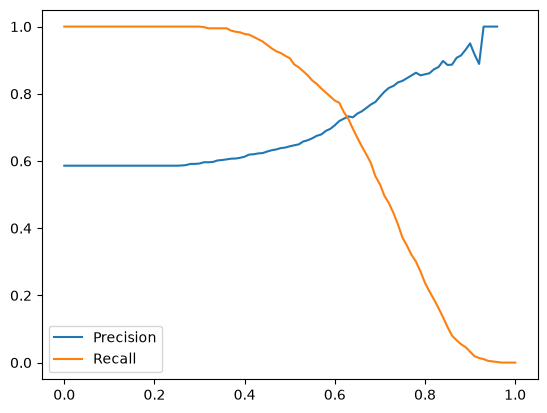

In [ ]:
plt.plot(df_scores.threshold, df_scores['precision'], label='Precision')
plt.plot(df_scores.threshold, df_scores['recall'], label='Recall')
plt.legend()

Answer

In [63]:
0.63

0.63

Q4: F1 score

In [ ]:
def precision_recall_f1_dataframe(y_val,y_pred):
    scores = []

    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
        
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
        
        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
    df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['f1'] = 2*((df_scores['precision'] * df_scores['recall'])/((df_scores['precision'] + df_scores['recall'])))

    return  df_scores


In [42]:
df_scores=precision_recall_f1_dataframe(y_val,y_pred)

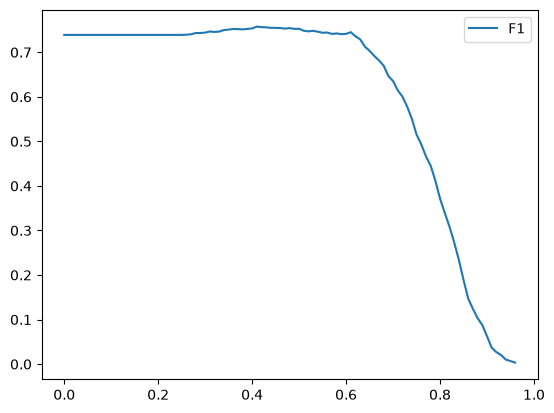

In [43]:
plt.plot(df_scores.threshold, df_scores['f1'], label='F1')
plt.legend()

Answer

In [45]:
best = df_scores.loc[df_scores['f1'].idxmax()]
print(best['threshold'], best['f1'])

0.41000000000000003 0.7576158940397352


Q5: 5-Fold CV standard deviation

In [48]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear',C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [49]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [65]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
C=1.0
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=C)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)


Answer

In [67]:
print('%.3f' % (np.std(scores)))

0.007


Q6: Best C

In [70]:
from tqdm.std import tqdm
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

n_splits = 5
cmeans=[]

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    
    cmeans.append([C,round(np.mean(scores),3)])
    # print('C=%s %.3f +- %.3f' % (C, round(np.mean(scores),3), round(np.std(scores),3)))

100%|██████████| 3/3 [00:01<00:00,  2.77it/s]


In [74]:
bestcmean=max(cmeans,key=lambda x:x[1])

Answer

In [73]:
bestcmean

[0.001, np.float64(0.749)]